# 21. Otomatik Veri Bilimi Ajanı

**Kategori:** AI Agents  
**Gerçek veri seti:** UCI Wine  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/109/wine](https://archive.ics.uci.edu/dataset/109/wine)  
**Amaç:** Veri kalitesini denetleyen, aday modelleri çapraz doğrulayan ve en iyisini kaydeden ajan akışı kurmak.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Ajanın kullanacağı gerçek veri ve EDA

In [2]:
from sklearn.datasets import load_wine
d = load_wine(as_frame=True)
df = d.frame.copy()
display(df.head())
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
display(audit)
print("Sınıf oranları:")
display(df.target.value_counts(normalize=True).sort_index().to_frame("oran").round(3))

Sınıf oranları:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


,dtype,missing,unique
alcohol,float64,0,126
malic_acid,float64,0,133
ash,float64,0,79
alcalinity_of_ash,float64,0,63
magnesium,float64,0,53
total_phenols,float64,0,97
flavanoids,float64,0,132
nonflavanoid_phenols,float64,0,39
proanthocyanins,float64,0,101
color_intensity,float64,0,132


,oran
target,
0,0.331
1,0.399
2,0.270


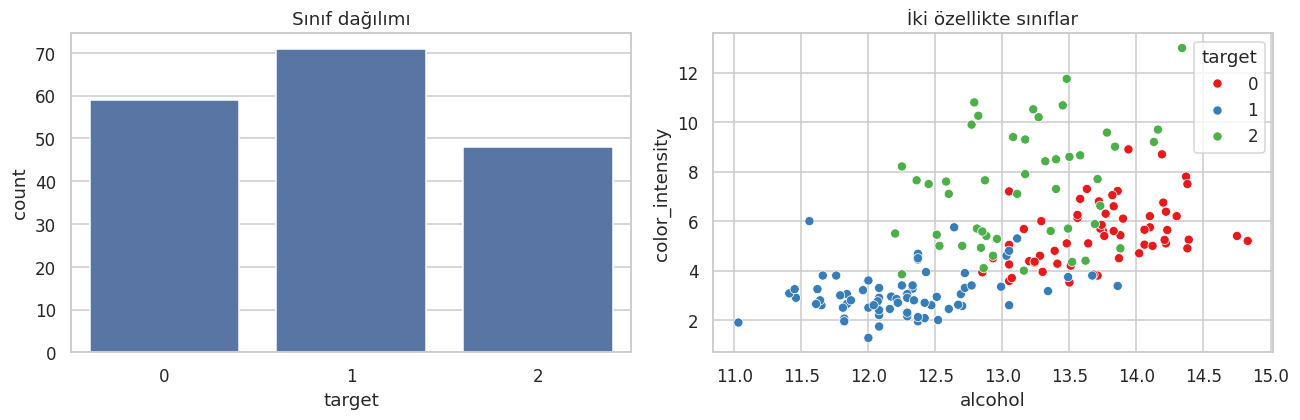

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="target", ax=axes[0]); axes[0].set(title="Sınıf dağılımı")
sns.scatterplot(data=df, x="alcohol", y="color_intensity", hue="target",
                palette="Set1", ax=axes[1]); axes[1].set(title="İki özellikte sınıflar")
plt.tight_layout(); plt.show()

## 2. Araç kullanan ajan akışı

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def data_audit(frame, target):
    return {
        "rows": len(frame), "features": frame.shape[1] - 1,
        "missing_cells": int(frame.isna().sum().sum()),
        "duplicate_rows": int(frame.duplicated().sum()),
        "minority_ratio": float(frame[target].value_counts(normalize=True).min()),
    }

def candidate_models():
    return {
        "Lojistik Regresyon": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2500)),
        "RBF-SVM": make_pipeline(StandardScaler(), SVC()),
        "Random Forest": RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE),
    }

X, y = d.data, d.target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = candidate_models()
cv_scores = pd.Series({name: cross_val_score(model, X, y, cv=cv, scoring="f1_macro").mean()
                       for name, model in models.items()}, name="CV macro-F1").sort_values(ascending=False)
best_name = cv_scores.index[0]
best_model = models[best_name].fit(X, y)
report = {"audit": data_audit(df, "target"), "scores": cv_scores.to_dict(),
          "decision": best_name, "criterion": "5-fold stratified CV macro-F1"}
display(cv_scores.to_frame().round(4))
print(json.dumps(report, indent=2, ensure_ascii=False))

{
  "audit": {
    "rows": 178,
    "features": 13,
    "missing_cells": 0,
    "duplicate_rows": 0,
    "minority_ratio": 0.2696629213483146
  },
  "scores": {
    "RBF-SVM": 0.9833573188343172,
    "Lojistik Regresyon": 0.9829048995413181,
    "Random Forest": 0.9783950617283951
  },
  "decision": "RBF-SVM",
  "criterion": "5-fold stratified CV macro-F1"
}


,CV macro-F1
RBF-SVM,0.9834
Lojistik Regresyon,0.9829
Random Forest,0.9784


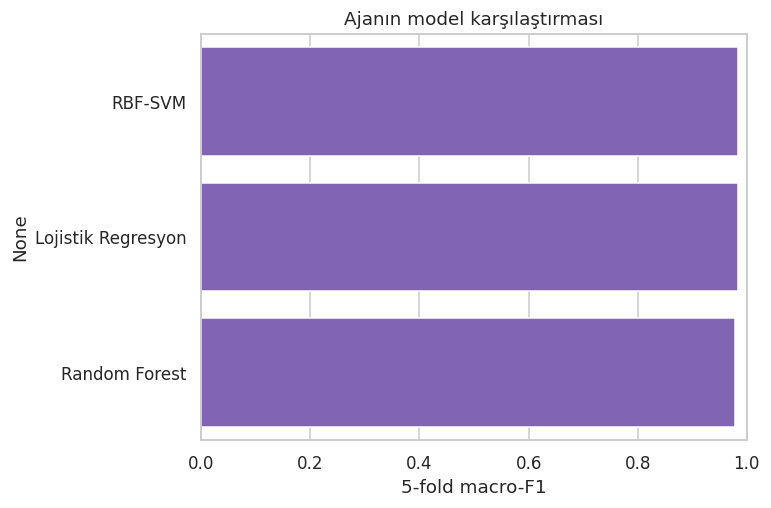

In [5]:
sns.barplot(x=cv_scores.values, y=cv_scores.index, color="#7E57C2")
plt.xlim(0, 1); plt.xlabel("5-fold macro-F1"); plt.title("Ajanın model karşılaştırması")
plt.show()
joblib.dump({"best_name": best_name, "best_model": best_model,
             "candidate_models": models, "cv_scores": cv_scores.to_dict(),
             "feature_names": d.feature_names, "target_names": d.target_names.tolist(),
             "audit": report["audit"]}, MODEL_DIR / "21_model_secim_ajani.joblib")
json.dump(report, open(RESULT_DIR / "21_model_secim_ajani.json", "w"),
          indent=2, ensure_ascii=False)

## Sonuç ve ajan tanımı

Bu çalışma yalnızca `if/else` ile sabit model seçmez. Ajan sırasıyla veri denetimi aracını,
aday-model aracını ve 5 katlı çapraz doğrulama aracını çalıştırır; ölçülebilir macro-F1 sonucuna göre
karar verir ve karar raporunu kaydeder. Harici LLM/API anahtarı gerektirmediği için notebook her
ortamda yeniden üretilebilir.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **otomatik model karşılaştırması ve deployment** biçimindedir.
Bu notebookta **araç tabanlı tekrarlanabilir ajan, veri denetimi, üç aday, stratified CV ve makinece okunabilir karar raporu** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).